<a href="https://colab.research.google.com/github/iGeology-Illinois/geol581-getting-started-with-python-osduarte2/blob/main/Oscar_Duarte_GEOL_581_Module_5_Slope_Stability_Analyses_no1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOL 581: Module 5 | Slope Stability Analyses

## Introduction

In this notebook, we will explore how to apply and compare different slope stability approaches, referencing the methods described in the textbook sections on kinematic and mechanical preconditions, plane/rotational sliding, and the method of slices (including Figs. 10.31–10.37, etc.). We will use Python to model:

- Plane sliding in non-cohesive soils (and how friction angle and slope angle interplay).  
- The method of slices in cohesive soils (membrane vs. flow net solutions).  
- Sensitivity analyses, to see how factor of safety changes with varying parameters.

Some key ideas from the referenced pages:

1. Kinematic and Mechanical Preconditions  
   - A slope can fail only if it is capable of forming a particular failure mechanism (kinematic condition)  
   - And if a trigger disturbs the force equilibrium (mechanical condition).

2. Plane Sliding vs. Rotational Sliding  
   - Plane sliding is when the failure surface is roughly planar (Fig. 10.31, 10.32).  
   - Rotational sliding is when the failure surface is curved, often occurring in cohesive soils (Fig. 10.34, 10.35).

3. Method of Slices  
   - We divide the potential sliding mass into vertical slices.  
   - Each slice’s forces (weight, cohesion, friction, pore-water pressures) are evaluated.  
   - Two approaches, referencing Fig. 10.37:  
     - Membrane solution: Groundwater is interpreted as acting along a membrane on the slip surface.  
     - Flow net solution: Uses equipotential lines and flow nets to apply seepage forces directly within each slice.

Below, you will find three main coding tasks, each preceded by explanatory Markdown cells that guide your analysis. This assignment is deliberately open-ended so you can adapt or extend the models to more complex scenarios.


In [ ]:
# Part 1: Basic Plane Sliding
# We'll begin with a simple function to estimate a factor of safety (FOS) for plane sliding.
# This function is intentionally simplified. Refer back to Figures 10.31 and 10.32 in the textbook
# for details about how to incorporate seepage forces, partial saturation, etc.

import numpy as np

def plane_sliding_fos(phi_deg, beta_deg):
    """
    Computes a very simplified factor of safety for plane sliding in non-cohesive soil.
    phi_deg : friction angle (degrees)
    beta_deg: slope angle (degrees)
    Returns : factor of safety (dimensionless)
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)

    # For demonstration: ratio of available friction to driving shear
    # This is NOT a full formula; adapt from the text's equations if desired.
    if np.tan(beta) == 0:
        return np.inf

    fos = np.tan(phi) / np.tan(beta)
    return fos

# Example usage:
phi_test = 20.0  # friction angle in degrees
beta_test = 35.0 # slope angle in degrees
fos_result = plane_sliding_fos(phi_test, beta_test)
print(f"Plane sliding FOS with phi={phi_test}°, beta={beta_test}°: {fos_result:.3f}")


Plane sliding FOS with phi=20.0°, beta=35.0°: 0.520


In [ ]:
import numpy as np

def plane_sliding_fos(phi_deg, beta_deg, gamma_soil, gamma_water=None, external_force=0.0, force_angle_deg=0.0):
    """
    Computes factor of safety for plane sliding in non-cohesive soil,
    considering buoyancy/seepage and external loads.

    Args:
        phi_deg (float): Friction angle (degrees).
        beta_deg (float): Slope angle (degrees).
        gamma_soil (float): Soil unit weight (kN/m^3).
        gamma_water (float, optional): Water unit weight (kN/m^3).
                                       If provided, seepage is considered. Defaults to None.
        external_force (float, optional): Magnitude of external force (kN). Defaults to 0.0.
        force_angle_deg (float, optional): Angle of external force with respect to the horizontal (degrees). Defaults to 0.0.

    Returns:
        float: Factor of safety (dimensionless).
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    force_angle = np.radians(force_angle_deg)  # Convert force angle to radians

    # Calculate driving force due to soil weight
    driving_force = np.tan(beta)

    # Calculate resisting force due to friction
    resisting_force = np.tan(phi)

    # Incorporate buoyancy/seepage if gamma_water is provided
    if gamma_water is not None:
        resisting_force *= (gamma_soil - gamma_water) / gamma_soil # Reduced resisting force

    # Incorporate external force
    driving_force -= external_force * np.sin(force_angle) / gamma_soil
    resisting_force += external_force * np.cos(force_angle) / gamma_soil

    # Calculate FOS
    if driving_force == 0:
        return np.inf # Handle zero division
    else:
        fos = resisting_force / driving_force
        return fos

# Example usage with buoyancy and external load:
phi_test = 20.0  # friction angle in degrees
beta_test = 35.0  # slope angle in degrees
gamma_soil = 18.0  # soil unit weight (kN/m^3)
gamma_water = 9.81  # water unit weight (kN/m^3)
external_force = 7.0  # external force (kN)
force_angle_deg = 30.0  # angle of external force (degrees)

fos_result = plane_sliding_fos(phi_test, beta_test, gamma_soil, gamma_water, external_force, force_angle_deg)
print(f"Plane sliding FOS: {fos_result:.3f}")

Plane sliding FOS: 0.993


In Part# 1 of a basic (simplified) Plane sliding model, if beta=phi, then the polygon of forces limit state is met. This is the maximum possible inclination of beta. The angles beta=20 and phi=35 on the first plane sliding example yields a FOS of 0.520. This slope is unstable as the driving forces exceed the resisting force, therefore, it poses a risk of failure. It beta=phi, then the FOS equals 1, meaning the forces are equilibrated and pose no failure risks due the neutral stability of the forces.

In the second example, additional parameters were added: soil unit weight, water unit weight, external forces acting on the slope, and angle of the external force. With the inclusion of these new parameters, the FOS increased to 0.993 based on the example values entered into the calculations. This FOS represents a more balanced model, but still slightly < 1, which results in an unstable configuration due the driving forces exceeding the resisting forces.



## Part 1 Instructions

1. Review how the equilibrium of forces is established for plane sliding in non-cohesive soil.  
   - Check Figures 10.31 and 10.32 for the polygon of forces.  
   - Account for friction angle φ and slope angle β.  
   - (Optionally) consider seepage forces if the groundwater table intersects the slope.

2. Modify the `plane_sliding_fos` function to incorporate additional parameters:
   - Buoyancy or seepage if the water table is parallel to the slope (Fig. 10.32).
   - External loads if relevant.

3. Discuss in a separate Markdown cell how your final formula differs from the simplified example above.


In [ ]:
# Part 2: Method of Slices (Membrane vs. Flow Net)
# For cohesive soils, we can implement a simplified method of slices approach.
# Reference Fig. 10.37 from the textbook. We'll build two functions:
#   - One using a "membrane" interpretation of groundwater
#   - One using a "flow net" approach with each slice having distinct pore pressures.

import numpy as np

def fos_slices_membrane(n_slices, slope_height, c, phi_deg, gamma_soil):
    """
    Very simplified demonstration of a 'membrane solution' approach.
    n_slices     : number of slices
    slope_height : total slope height (m)
    c            : cohesion (kN/m^2)
    phi_deg      : friction angle (degrees)
    gamma_soil   : soil unit weight (kN/m^3)
    Returns an approximate factor of safety.
    """
    phi = np.radians(phi_deg)

    # For demonstration: assume each slice is of equal width
    slice_width = 2.0  # arbitrary
    slice_heights = np.linspace(1, slope_height, n_slices)

    R_total = 0.0
    D_total = 0.0

    for h_slice in slice_heights:
        # Weight of slice (assuming some unit thickness)
        W = gamma_soil * slice_width * h_slice

        # Simplistic normal force
        N = W * np.cos(phi)

        # Shear resistance from cohesion plus friction
        S_res = c * slice_width + N * np.tan(phi)

        # Driving force
        D = W * np.sin(phi)

        R_total += S_res
        D_total += D

    if D_total == 0:
        return np.inf
    return R_total / D_total


def fos_slices_flownet(n_slices, slope_height, c, phi_deg, gamma_soil):
    """
    Simplified demonstration of a 'flow net solution' approach.
    We'll add random or parametric pore water pressure for each slice.
    """
    phi = np.radians(phi_deg)
    slice_width = 2.0
    slice_heights = np.linspace(1, slope_height, n_slices)

    R_total = 0.0
    D_total = 0.0

    rng = np.random.default_rng(seed=42)  # reproducible random values

    for h_slice in slice_heights:
        W = gamma_soil * slice_width * h_slice

        # Assign a random pore pressure ratio in [0, 0.3]
        ru = rng.random() * 0.3

        # Effective normal force
        N_eff = (W * np.cos(phi)) * (1 - ru)

        # Shear resistance
        S_res = c * slice_width + N_eff * np.tan(phi)

        # Driving force
        D = W * np.sin(phi)

        R_total += S_res
        D_total += D

    if D_total == 0:
        return np.inf
    return R_total / D_total

# Demonstration usage:
fos_membrane_demo = fos_slices_membrane(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0)
fos_flownet_demo = fos_slices_flownet(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0)

print(f"Membrane solution FOS (example): {fos_membrane_demo:.3f}")
print(f"Flow net solution FOS (example): {fos_flownet_demo:.3f}")


Membrane solution FOS (example): 1.239
Flow net solution FOS (example): 1.094


In [ ]:
import numpy as np

def fos_slices_membrane(n_slices, slope_height, c, phi_deg, gamma_soil):
    """
    Improved membrane solution using moment equilibrium.
    """
    phi = np.radians(phi_deg)

    slice_height = slope_height / n_slices

    R_total = 0.0  # Resistance
    D_total = 0.0  # Driving force
    moments = 0.0  # Moments for equilibrium

    for i in range(n_slices):
        h_slice = slice_height * (i + 0.5)  # Center height of the slice
        W = gamma_soil * 2.0 * h_slice  # Weight of the slice with width (2.0m assumed)

        N = W * np.cos(phi)  # Normal force
        S_res = c * 2.0 + N * np.tan(phi)  # Shear resistance

        D = W * np.sin(phi)  # Driving force from weight

        # Moment contributions about the slice base
        moment_arm = h_slice * np.cos(phi)  # perpendicular distance to the driving force
        moments += D * moment_arm  # Contributing moment from driving force

        R_total += S_res

    if moments == 0:
        return np.inf

    return R_total / moments

def fos_slices_flownet(n_slices, slope_height, c, phi_deg, gamma_soil):
    """
    Improved flow net solution using moment equilibrium.
    """
    phi = np.radians(phi_deg)
    slice_height = slope_height / n_slices

    R_total = 0.0
    moments = 0.0

    rng = np.random.default_rng(seed=42)  # Reproducible random values

    for i in range(n_slices):
        h_slice = slice_height * (i + 0.5)  # Center height of the slice
        W = gamma_soil * 2.0 * h_slice  # Weight of the slice

        # Assign a random pore pressure ratio in [0, 0.3]
        ru = rng.random() * 0.3

        N_eff = (W * np.cos(phi)) * (1 - ru)  # Effective normal force
        S_res = c * 2.0 + N_eff * np.tan(phi)  # Shear resistance

        D = W * np.sin(phi)  # Driving force from weight

        # Moment contributions about the slice base
        moment_arm = h_slice * np.cos(phi)  # perpendicular distance to the driving force
        moments += D * moment_arm  # Contributing moment from driving force

        R_total += S_res

    if moments == 0:
        return np.inf

    return R_total / moments

# Demonstration usage:
fos_membrane_demo = fos_slices_membrane(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0)
fos_flownet_demo = fos_slices_flownet(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0)

print(f"Membrane solution FOS (revised): {fos_membrane_demo:.3f}")
print(f"Flow net solution FOS (revised): {fos_flownet_demo:.3f}")

Membrane solution FOS (revised): 0.211
Flow net solution FOS (revised): 0.187


The functions calculate the resisting and driving forces through each individual iterative slice. Additionally, both forces are incremented from respective forces from each slice. The current models assumes a straight slip surface. It is possible to include real data from an actual (not straight) slip surface to reflect realistic slip surface geometry. The angle of each slice base can be implemented into the force calculations to reflect a more realistic scenario.

The modified code in the cell above is modified version of the previous cell. It now includes moment equilibrium which incorporates moments about the base of each slice into the FOS calculation. Additionally, the height of each slice is to be calculated based on the total slope height / number of slices (n). Also the weight of slice is considered into the FOS calculation.

## Part 2 Instructions

1. Analyze the functions `fos_slices_membrane` and `fos_slices_flownet`:
   - How are they currently summing the forces among slices?
   - Where can you incorporate real data or a more rigorous approach (e.g., geometry of the slip surface, slice base angles, etc.)?

2. Revise one or both functions to reflect your course’s recommended method for computing the factor of safety.
   - You might need to include more realistic geometry or moment equilibrium.  
   - Alternatively, you can keep it simple but justify your assumptions.

3. Document how your approach corresponds to the textbook’s Figures 10.37 and 10.38 (membrane vs. flow net solutions, interacting blocks, etc.).


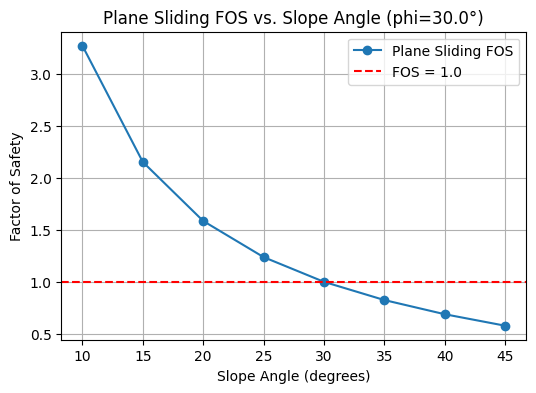

In [ ]:
# Part 3: Sensitivity Analysis & Visualization
# Let's conduct a short sensitivity analysis by varying slope angle or pore pressure ratio,
# compute factor of safety, and then plot the results.

import numpy as np
import matplotlib.pyplot as plt

def plane_sliding_sensitivity(phi_deg, slope_angles):
    """
    Returns a list of factor of safety values for an array of slope angles
    using the plane_sliding_fos function from Part 1.
    """
    fos_list = []
    for beta in slope_angles:
        fos_val = plane_sliding_fos(phi_deg, beta)
        fos_list.append(fos_val)
    return fos_list

slope_angles_array = range(10, 46, 5)  # from 10 to 45 in steps of 5
phi_demo = 30.0
fos_vs_beta = plane_sliding_sensitivity(phi_demo, slope_angles_array)

plt.figure(figsize=(6,4))
plt.plot(list(slope_angles_array), fos_vs_beta, 'o-', label="Plane Sliding FOS")
plt.axhline(y=1.0, color='r', linestyle='--', label="FOS = 1.0")
plt.xlabel("Slope Angle (degrees)")
plt.ylabel("Factor of Safety")
plt.title(f"Plane Sliding FOS vs. Slope Angle (phi={phi_demo}°)")
plt.grid(True)
plt.legend()
plt.show()

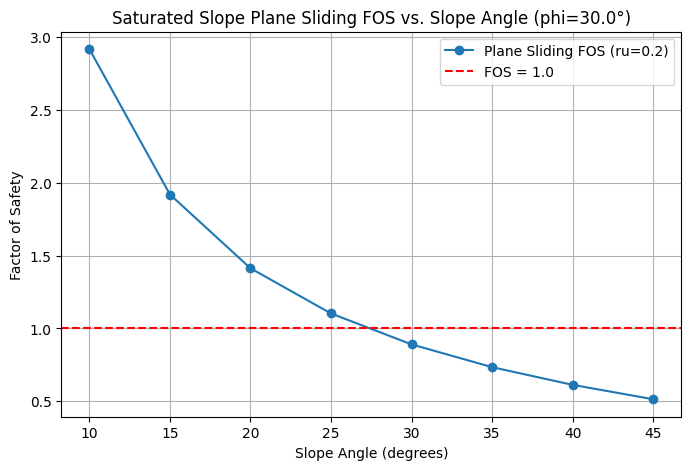

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plane_sliding_fos(phi_deg, beta_deg, ru):
    """
    A plane sliding factor of safety calculation based on slope angle,
    friction angle, and pore pressure ratio.

    Arguments:
        phi_deg: internal friction angle (degrees)
        beta_deg: slope angle (degrees)
        ru: pore pressure ratio (0 to 1)

    Returns:
        Factor of Safety (FOS)
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)

    # Calculate normal and effective normal forces
    # Assume unit weight of water is typically around 9.81 kN/m^3
    # Assume unit weight of soil to be a certain value (e.g., 18 kN/m^3)
    gamma_soil = 18.0  # kN/m^3
    gamma_water = 9.81  # kN/m^3

    # Effective normal force calculation
    # Effective weight = weight of soil - pore pressure
    effective_weight = gamma_soil * np.cos(beta) * (1 - ru * gamma_water / gamma_soil)

    # Calculate FOS based on effective normal and shear resistance
    return np.tan(phi) / np.tan(beta) * (effective_weight / (gamma_soil * np.cos(beta)))

def plane_sliding_sensitivity(phi_deg, slope_angles, ru):
    """
    Returns a list of factor of safety values for an array of slope angles
    using the plane_sliding_fos function.
    """
    fos_list = []
    for beta in slope_angles:
        fos_val = plane_sliding_fos(phi_deg, beta, ru)
        fos_list.append(fos_val)
    return fos_list

# Sensitivity Analysis
slope_angles_array = range(10, 46, 5)  # from 10 to 45 in steps of 5
phi_demo = 30.0
pore_pressure_ratio = 0.2  # Example pore pressure ratio

fos_vs_beta = plane_sliding_sensitivity(phi_demo, slope_angles_array, pore_pressure_ratio)

# Plot Results
plt.figure(figsize=(8, 5))
plt.plot(list(slope_angles_array), fos_vs_beta, 'o-', label=f"Plane Sliding FOS (ru={pore_pressure_ratio})")
plt.axhline(y=1.0, color='r', linestyle='--', label="FOS = 1.0")
plt.xlabel("Slope Angle (degrees)")
plt.ylabel("Factor of Safety")
plt.title(f"Saturated Slope Plane Sliding FOS vs. Slope Angle (phi={phi_demo}°)")
plt.grid(True)
plt.legend()
plt.show()

The modified code above incorporates pore pressure ratio as the original code did not include it. The pore pressure ratio affects the FOS by modifying the effective weight of the soil. In the original code, the FOS can quickly drop to less than one when the slope angle is increased to > ~27 degrees. If less than 27 degrees, then the FOS remains above meaning that the model is stable and poses no risks of failure.

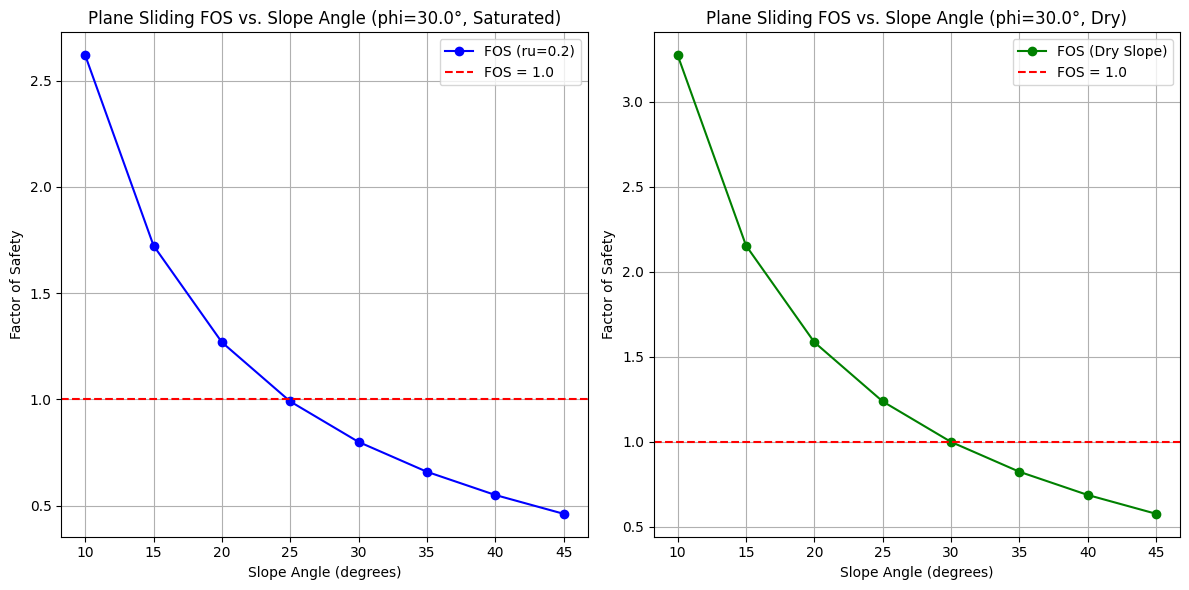

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plane_sliding_fos(phi_deg, beta_deg, ru):
    """
    Plane sliding factor of safety calculation based on slope angle,
    friction angle, and pore pressure ratio.

    Arguments:
        phi_deg: internal friction angle (degrees)
        beta_deg: slope angle (degrees)
        ru: pore pressure ratio (0 to 1)

    Returns:
        Factor of Safety (FOS)
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)

    # Assume unit weight of soil to be a certain value (e.g., 18 kN/m^3)
    gamma_soil = 18.0  # kN/m^3

    # Calculate effective weight
    effective_weight = gamma_soil * np.cos(beta) * (1 - ru)  # Adjust for pore pressure

    # Calculate FOS based on effective normal and shear resistance
    return np.tan(phi) / np.tan(beta) * (effective_weight / (gamma_soil * np.cos(beta)))

def plane_sliding_sensitivity(phi_deg, slope_angles, ru):
    """
    Returns a list of factor of safety values for an array of slope angles
    using the plane_sliding_fos function.
    """
    fos_list = []
    for beta in slope_angles:
        fos_val = plane_sliding_fos(phi_deg, beta, ru)
        fos_list.append(fos_val)
    return fos_list

# Sensitivity Analysis Parameters
slope_angles_array = range(10, 46, 5)  # from 10 to 45 in steps of 5
phi_demo = 30.0
pore_pressure_ratio_saturated = 0.2  # Example pore pressure ratio for the saturated slope
pore_pressure_ratio_dry = 0.0  # Completely dry slope

# Compute Factor of Safety values
fos_vs_beta_saturated = plane_sliding_sensitivity(phi_demo, slope_angles_array, pore_pressure_ratio_saturated)
fos_vs_beta_dry = plane_sliding_sensitivity(phi_demo, slope_angles_array, pore_pressure_ratio_dry)

# Create two plots in one figure
plt.figure(figsize=(12, 6))

# Subplot for Saturated Slope
plt.subplot(1, 2, 1)
plt.plot(list(slope_angles_array), fos_vs_beta_saturated, 'o-', color='blue', label=f"FOS (ru={pore_pressure_ratio_saturated})")
plt.axhline(y=1.0, color='r', linestyle='--', label="FOS = 1.0")
plt.xlabel("Slope Angle (degrees)")
plt.ylabel("Factor of Safety")
plt.title(f"Plane Sliding FOS vs. Slope Angle (phi={phi_demo}°, Saturated)")
plt.grid(True)
plt.legend()

# Subplot for Dry Slope
plt.subplot(1, 2, 2)
plt.plot(list(slope_angles_array), fos_vs_beta_dry, 'o-', color='green', label="FOS (Dry Slope)")
plt.axhline(y=1.0, color='r', linestyle='--', label="FOS = 1.0")
plt.xlabel("Slope Angle (degrees)")
plt.ylabel("Factor of Safety")
plt.title(f"Plane Sliding FOS vs. Slope Angle (phi={phi_demo}°, Dry)")
plt.grid(True)
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

The code above represents a saturated slope and a dry slope with no pore pressure ratio. In the dry slope model, when the slope angle and friction angles are equal to each other, the FOS is always 1. In the saturated slope example, considering  a pore pressure ratio of 0.2, FOS will results >= 1 only when the slope angle is <= to ~25 degrees (assuming a friction angle of 30). By including a pore pressure ratio into this analysis, the FOS values decrease due to the weight of the overlying soil and water paramters.

## Part 3 Instructions

1. Experiment with the above sensitivity analysis:
   - Vary angles, friction angles, cohesion, or random pore pressure parameters.
   - Compare how quickly your slope’s FOS drops below 1.0.

2. Visualize your final results:
   - Possibly create multiple subplots for different conditions (e.g., dry vs. saturated slope).
   - Show how the FOS changes with each parameter and discuss your findings.

3. Write a brief conclusion in another Markdown cell:
   - Summarize the main insights from your numerical experiments.
   - Reflect on how well these simplified models approximate real slope behavior.

### Submission Notes

- Upload your final notebook to the class repository.
- Ensure that each part (plane sliding, method of slices, and sensitivity analysis) is fully documented.
- Discuss any real-world complexities (non-homogeneous soils, layered strata, seismic loads, etc.) that are simplified here.
- Reference the relevant textbook pages (Figs. 10.31–10.38) wherever applicable.

End of Assignment


To conlude the findings and observations from this experiment, slope stability is sensitive to a variety of factors such as friction angles, slope angles, pore water pressures, external forces. These factors directly affect the FOS values deeming the modeled sloep stable or prone to instability. Experimental values were used to modify each of the parameters, therefore, providing a visual representation of the sensitivity of the functions relative to each parameter that was adjusted. Each modification to the original code was documented in text cell below the modified code.

These 'simplified' models provided valuable insights in terms of slope stabillity in a real-world scenario. It must be noted that omplexities such as heterogeneity of soil, layered strata, and seismic loads were not accounted for in the code. Conversely, these real-world complexities should be considered when determining factors of safety for slopes for any real-world cases as these paramters are crucial for making important and well informe decisions. Comprehensive site investigations should be conducted to capture significant parameters that constitute the stability of a slope. Therefore, engineering geologists can be suited to make well informed and appropriate decisions to ensure projects are constructed effectively.